# **Serie 2 — Procesamiento Digital de Señales**
## **Correlación y correlación cruzada: detección de frecuencias**

# **Integrantes**
Nombre: Jaramillo Rodriguez Leslie Citlalli

Número de cuenta: 320318931

Grupo = 03



Nombre:López Montero Ivana Abigail

Número de cuenta: 320022027

Grupo = 03


Nombre: Salas Hernandez Camila Alexandra

Número de cuenta: 320332825


**Materia:** Procesamiento Digital de Señales  

**Fecha:** 21 Sep 2026


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (11, 3.6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

np.random.seed(0)   # reproducibilidad para el ejercicio de ruido
print("Entorno listo. NumPy:", np.__version__)

Entorno listo. NumPy: 2.1.3


In [2]:
from numpy.lib.stride_tricks import sliding_window_view

def ventanas(x, M):
    """
    Razonamiento:
    Para no usar bucles al desplazar la señal, rellenamos x con M-1 ceros.
    Luego extraemos todas las ventanas posibles de tamaño M como una matriz W,
    donde cada fila representa a x alineada con un desfase k.
    """
    ceros = np.zeros(M - 1)
    x_ext = np.concatenate([ceros, np.asarray(x, dtype=float), ceros])
    return sliding_window_view(x_ext, M)          # forma (N+M-1, M), sin copiar datos


def correlacion_cruzada(x, y):
    """
    Razonamiento:
    Generamos la matriz de ventanas de x y la multiplicamos directamente por el
    vector y mediante un producto matriz-vector. Esto calcula en una sola operación
    todos los productos punto para los desplazamientos desde -(M-1) hasta N-1 sin iterar.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    N, M = len(x), len(y)

    W = ventanas(x, M)                            # cada fila = una ventana de x
    R = W @ y                                     # N+M-1 productos punto de una sola vez
    lags = np.arange(-(M - 1), N)
    return lags, R


def autocorrelacion(x):
    """
    Razonamiento:
    Es la correlación cruzada de una señal consigo misma. Reutilizamos la función
    "correlacion_cruzada(x, x)" para obtener el nivel de solapamiento y la energía
    en cada desfase.
    """
    return correlacion_cruzada(x, x)


def correlaciones_multiples(x, Y):
    """
    Razonamiento:
    Multiplicamos la matriz de ventanas por la transpuesta de las referencias,
    así obtenemos todas las correlaciones cruzadas.
    """
    Y = np.atleast_2d(np.asarray(Y, dtype=float))
    N, M = len(x), Y.shape[1]
    R = (ventanas(x, M) @ Y.T).T                  # (N+M-1, M) @ (M, F) -> traspuesta
    return np.arange(-(M - 1), N), R


# --- Verificacion contra NumPy -------------------------------------------
_x = [1, 2, 3, 2, 1]
_y = [0, 1, 2]
_lags, _R = correlacion_cruzada(_x, _y)
_ref = np.correlate(_x, _y, mode="full")
print("Producto matriz-vector :", _R)
print("np.correlate (ref)     :", _ref)
print("Coinciden:", np.allclose(_R, _ref))

# Comprobacion de que una fila es un producto punto:
k = 1
p = k + len(_y) - 1
print(f"\nFila del lag k={k}: ventana de x =", ventanas(_x, len(_y))[p],
      " ->  producto punto con y =", np.dot(ventanas(_x, len(_y))[p], _y))

Producto matriz-vector : [2. 5. 8. 7. 4. 1. 0.]
np.correlate (ref)     : [2 5 8 7 4 1 0]
Coinciden: True

Fila del lag k=1: ventana de x = [2. 3. 2.]  ->  producto punto con y = 7.0


---
# Ejercicio 1 — Autocorrelación de una señal discreta
Consider the discrete-time signal
$$x[n] = \{1,\,2,\,3,\,2,\,1\},\qquad n = 0,\dots,4$$

a) Compute Rₓₓ[k] manually.

b) Implement the calculation in Python.

c) Plot x[n] and Rₓₓ[k].

d) At which lag is the maximum obtained?

e) Describe the symmetry observed in the autocorrelation.


In [3]:
# (b) Implementacion en Python
"""
Razonamiento:
Usamos la función autocorrelacion(x1), que con un for va multiplicando x[n+k]x[n]
solo en donde no da ceros, luego se valida que en el centro coincida con la energía y
con lo que da np.correlate.
"""
x1 = np.array([1, 2, 3, 2, 1], dtype=float)
lags1, Rxx1 = autocorrelacion(x1)

print("k      :", lags1)
print("Rxx[k] :", Rxx1)
print()
print("Verificacion con np.correlate:", np.correlate(x1, x1, 'full'))
print("Energia de la senal sum(x^2) =", np.sum(x1**2), " -> coincide con Rxx[0] =", Rxx1[lags1 == 0][0])

k      : [-4 -3 -2 -1  0  1  2  3  4]
Rxx[k] : [ 1.  4. 10. 16. 19. 16. 10.  4.  1.]

Verificacion con np.correlate: [ 1.  4. 10. 16. 19. 16. 10.  4.  1.]
Energia de la senal sum(x^2) = 19.0  -> coincide con Rxx[0] = 19.0


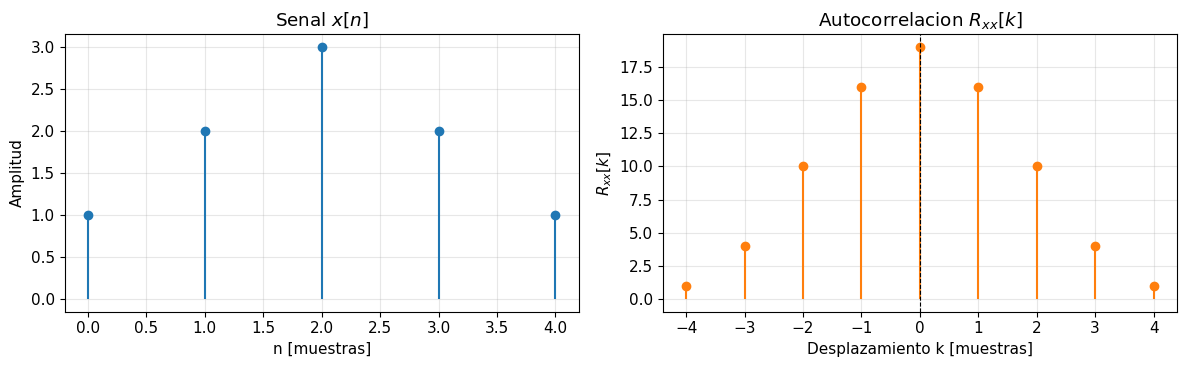

In [4]:
# (c) Graficas
"""
Razonamiento:
Con ayuda de stem graficamos la señal de entrada y la autocorrelación final. En la
gráfica se ve que el pico esta centrado en cero y va decayendo en forma
de espejo hacia ambos lados.
"""
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))

ax[0].stem(np.arange(len(x1)), x1, basefmt=" ")
ax[0].set_title("Senal $x[n]$")
ax[0].set_xlabel("n [muestras]"); ax[0].set_ylabel("Amplitud")

ax[1].stem(lags1, Rxx1, basefmt=" ", linefmt="C1-", markerfmt="C1o")
ax[1].axvline(0, color="k", lw=0.8, ls="--")
ax[1].set_title(r"Autocorrelacion $R_{xx}[k]$")
ax[1].set_xlabel("Desplazamiento k [muestras]"); ax[1].set_ylabel(r"$R_{xx}[k]$")

plt.tight_layout(); plt.show()

In [5]:
# (d) Lag del maximo
"""
Razonamiento:
El valor máximo fue 19 y cayó exactamente en k = 0, esto pasa porque una
señal nunca se parecerá más a otra señal que a sí misma sin desfasarse, y ese valor
equivale a la energía total de la señal.
"""
k_max = lags1[np.argmax(Rxx1)]
print(f"(d) El maximo vale {Rxx1.max():.0f} y ocurre en k = {k_max}")

# (e) Verificacion numerica de la simetria par
print("(e) Rxx[k] == Rxx[-k] para todo k ->", np.allclose(Rxx1, Rxx1[::-1]))

(d) El maximo vale 19 y ocurre en k = 0
(e) Rxx[k] == Rxx[-k] para todo k -> True


---
# Ejercicio 2 — Correlación cruzada y desplazamiento temporal
Consider
$$x[n]=\{0,1,2,3,2,1,0\},\qquad y[n]=\{0,0,0,1,2,3,2,1,0\}$$


a) Plot both signals.

b) Compute Rₓᵧ[k].

c) Plot the cross-correlation.

d) Determine the lag corresponding to its maximum.

e) Explain what this lag tells you about the relative position of the signals.

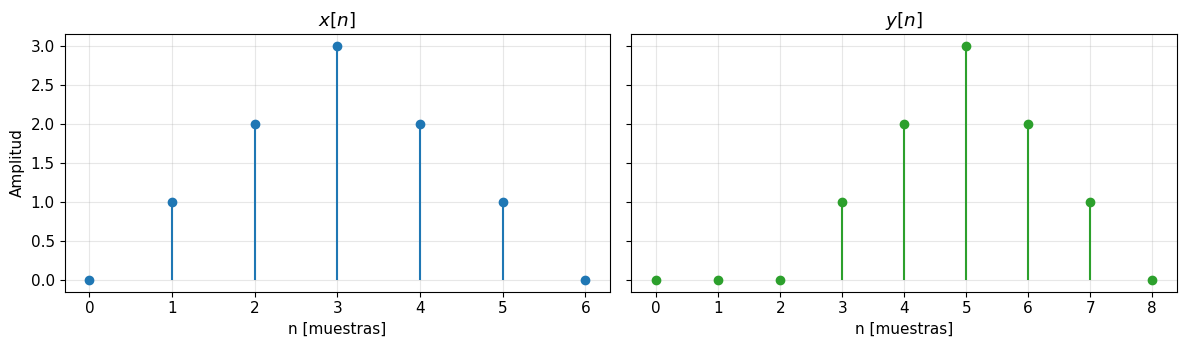

In [6]:
# (a) Graficar ambas senales
"""
Razonamiento:
Graficamos las dos para compararlas visualmente, estas tienen la misma forma,
pero en y[n] empieza 2 muestras después.
"""
x2 = np.array([0, 1, 2, 3, 2, 1, 0], dtype=float)
y2 = np.array([0, 0, 0, 1, 2, 3, 2, 1, 0], dtype=float)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
ax[0].stem(np.arange(len(x2)), x2, basefmt=" ")
ax[0].set_title("$x[n]$"); ax[0].set_xlabel("n [muestras]"); ax[0].set_ylabel("Amplitud")
ax[1].stem(np.arange(len(y2)), y2, basefmt=" ", linefmt="C2-", markerfmt="C2o")
ax[1].set_title("$y[n]$"); ax[1].set_xlabel("n [muestras]")
plt.tight_layout(); plt.show()

In [7]:
# (b) Correlacion cruzada
"""
Razonamiento:
Como y[n] = x[n-2], al sustituirla en la fórmula de correlación cruzada fue
la autocorrelación dada en k+2. Se calculo la sumatoria desplazando las señales
y verificamos que los resultados coincidieran con np.correlate.
"""
lags2, Rxy2 = correlacion_cruzada(x2, y2)
for k, v in zip(lags2, Rxy2):
    print(f"  k = {k:3d}   Rxy = {v:5.0f}")
print("\nVerificacion:", np.allclose(Rxy2, np.correlate(x2, y2, 'full')))

  k =  -8   Rxy =     0
  k =  -7   Rxy =     0
  k =  -6   Rxy =     1
  k =  -5   Rxy =     4
  k =  -4   Rxy =    10
  k =  -3   Rxy =    16
  k =  -2   Rxy =    19
  k =  -1   Rxy =    16
  k =   0   Rxy =    10
  k =   1   Rxy =     4
  k =   2   Rxy =     1
  k =   3   Rxy =     0
  k =   4   Rxy =     0
  k =   5   Rxy =     0
  k =   6   Rxy =     0

Verificacion: True


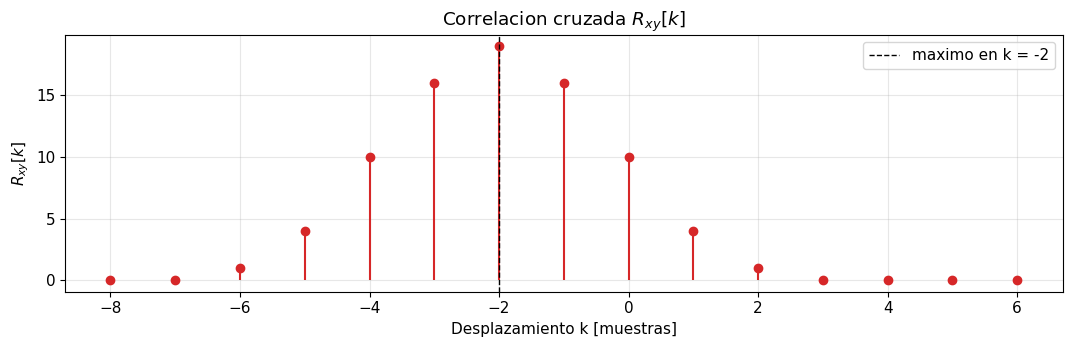

(d) Maximo = 19 en el lag k = -2


In [8]:
# (c) y (d)
"""
Razonamiento:
Graficamos la correlación cruzada y pusimos una línea punteada en el punto de
mayor coincidencia para marcar el pico. Con argmax sacamos el valor más alto,
que es 19 y pasa en el lag donde k = -2.
"""
k2 = lags2[np.argmax(Rxy2)]

plt.figure()
plt.stem(lags2, Rxy2, basefmt=" ", linefmt="C3-", markerfmt="C3o")
plt.axvline(k2, color="k", ls="--", lw=1, label=f"maximo en k = {k2}")
plt.title(r"Correlacion cruzada $R_{xy}[k]$")
plt.xlabel("Desplazamiento k [muestras]"); plt.ylabel(r"$R_{xy}[k]$")
plt.legend(); plt.tight_layout(); plt.show()

print(f"(d) Maximo = {Rxy2.max():.0f} en el lag k = {k2}")

---
# Ejercicio 3 — Detección de un patrón conocido
A receiver observes
$$x[n]=\{0,0,1,-1,2,1,-1,0,0\}$$
and searches for the pattern
$$\qquad p[n]=\{1,-1,2,1,-1\}$$

a) Compute the cross-correlation between x[n] and p[n].

b) Plot the result.

c) Determine where the pattern occurs in x[n].

d) Explain why correlation can be used as a detection mechanism.

In [9]:
"""
Razonamiento:
El valor más alto de correlación se da cuando el patrón p[n] se alinea exactamente
con la parte de x[n] que es igual a él, dando como resultado la energía del patrón
(1+1+4+1+1=8).
"""
x3 = np.array([0, 0, 1, -1, 2, 1, -1, 0, 0], dtype=float)
p3 = np.array([1, -1, 2, 1, -1], dtype=float)

lags3, Rxp3 = correlacion_cruzada(x3, p3)
k3 = lags3[np.argmax(Rxp3)]

for k, v in zip(lags3, Rxp3):
    marca = "  <== MAXIMO" if k == k3 else ""
    print(f"  k = {k:3d}   Rxp = {v:5.0f}{marca}")

print(f"\nEnergia del patron sum(p^2) = {np.sum(p3**2):.0f}")

  k =  -4   Rxp =     0
  k =  -3   Rxp =     0
  k =  -2   Rxp =    -1
  k =  -1   Rxp =     2
  k =   0   Rxp =    -1
  k =   1   Rxp =    -2
  k =   2   Rxp =     8  <== MAXIMO
  k =   3   Rxp =    -2
  k =   4   Rxp =    -1
  k =   5   Rxp =     2
  k =   6   Rxp =    -1
  k =   7   Rxp =     0
  k =   8   Rxp =     0

Energia del patron sum(p^2) = 8


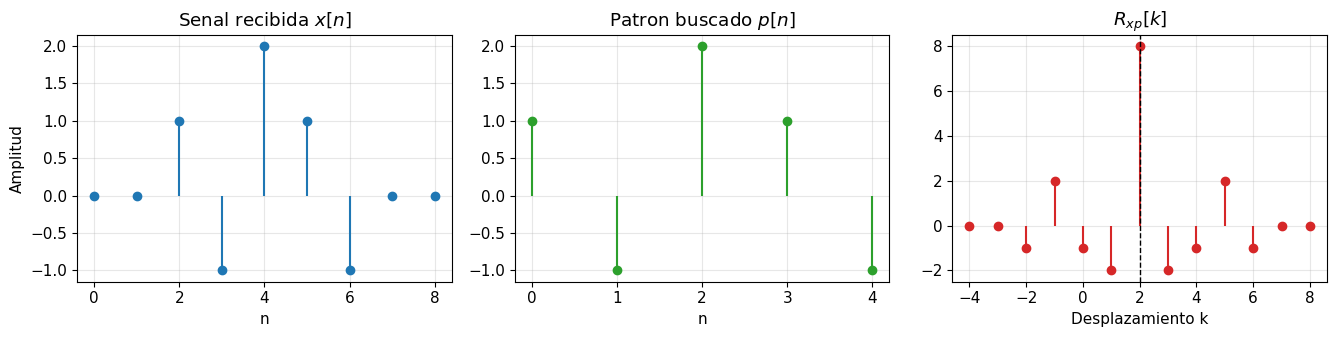

(c) El patron comienza en el indice n = 2 de x[n]
    x[2:7] = [ 1. -1.  2.  1. -1.]


In [10]:
# (b) Graficas
"""
Razonamiento:
Graficamos x[n], el patrón p[n] y la correlación cruzada para ver cómo la
correlación se queda baja en casi todo el tiempo y solo sube en un punto.
"""
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.5))

ax[0].stem(np.arange(len(x3)), x3, basefmt=" ")
ax[0].set_title("Senal recibida $x[n]$"); ax[0].set_xlabel("n"); ax[0].set_ylabel("Amplitud")

ax[1].stem(np.arange(len(p3)), p3, basefmt=" ", linefmt="C2-", markerfmt="C2o")
ax[1].set_title("Patron buscado $p[n]$"); ax[1].set_xlabel("n")

ax[2].stem(lags3, Rxp3, basefmt=" ", linefmt="C3-", markerfmt="C3o")
ax[2].axvline(k3, color="k", ls="--", lw=1)
ax[2].set_title(r"$R_{xp}[k]$"); ax[2].set_xlabel("Desplazamiento k")

plt.tight_layout(); plt.show()

print(f"(c) El patron comienza en el indice n = {k3} de x[n]")
print(f"    x[{k3}:{k3+len(p3)}] =", x3[k3:k3+len(p3)])

---
# Ejercicio 4 — Autocorrelación de una sinusoide
Generate
$$x(t)=\sin(2\pi\cdot 5t),\qquad 0\le t\le 2\ \text{s},\qquad f_s=100\ \text{Hz}$$


a) Plot the signal.

b) Compute and plot its autocorrelation.

c) Measure the distance, in samples, between consecutive autocorrelation maxima.

d) Convert this distance into seconds.

e) What relationship do you observe between this value and the frequency of the original signal?

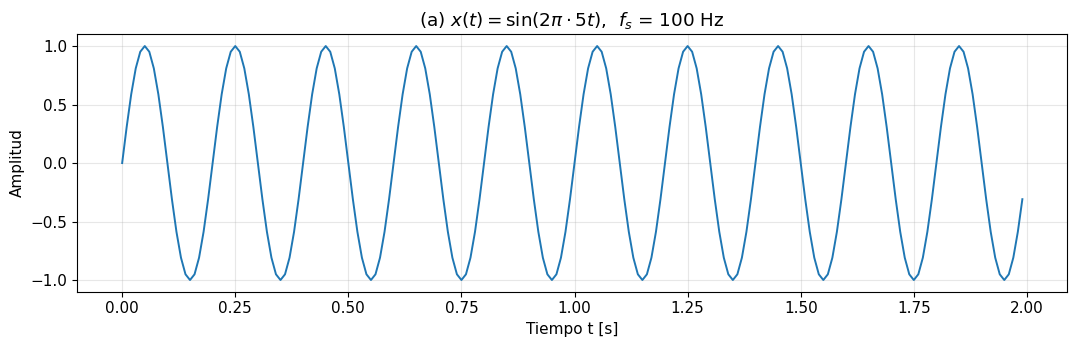

Numero de muestras N = 200


In [11]:
"""
Razonmaniento:
Graficamos la señal senoidal de 5Hz muestreada a 100Hz durante 2 segundos,
es decir, con 200 muestras para poder verificar sus ciclos.
"""
fs = 100.0                       # frecuencia de muestreo [Hz]
t  = np.arange(0, 2, 1/fs)       # vector de tiempo [s]
N  = len(t)
x4 = np.sin(2*np.pi*5*t)

# (a) Grafica de la senal
plt.figure()
plt.plot(t, x4, lw=1.4)
plt.title("(a) $x(t) = \\sin(2\\pi \\cdot 5t)$,  $f_s$ = 100 Hz")
plt.xlabel("Tiempo t [s]"); plt.ylabel("Amplitud")
plt.tight_layout(); plt.show()

print("Numero de muestras N =", N)

Coincide con np.correlate: True


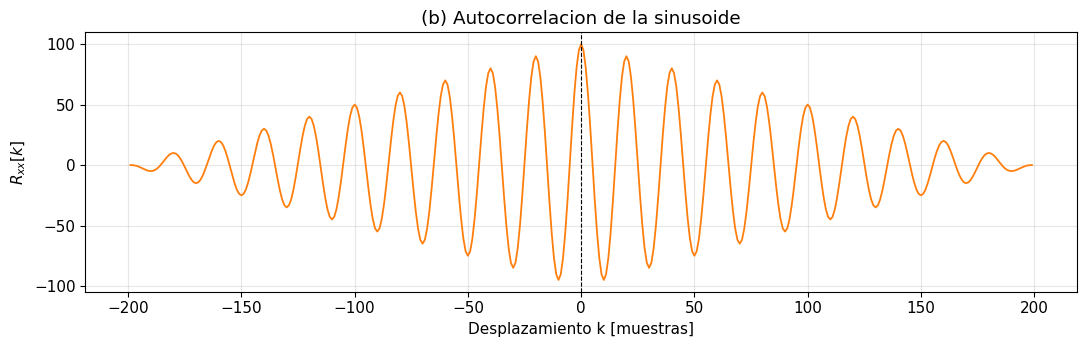

In [12]:
# (b) Autocorrelacion
"""
Razonamiento:
Calculamos la autocorrelación usando la función autocorrelacion(x4).
Aunque se pierde la fase original del seno, la salida nos da una onda cosenoidal
con su pico principal en k=0 que conserva intacto el periodo de la señal.
"""
lags4, Rxx4 = autocorrelacion(x4)
print("Coincide con np.correlate:", np.allclose(Rxx4, np.correlate(x4, x4, 'full')))

plt.figure()
plt.plot(lags4, Rxx4, lw=1.3, color="C1")
plt.axvline(0, color="k", lw=0.8, ls="--")
plt.title("(b) Autocorrelacion de la sinusoide")
plt.xlabel("Desplazamiento k [muestras]"); plt.ylabel(r"$R_{xx}[k]$")
plt.tight_layout(); plt.show()

In [13]:
# (c) Distancia entre maximos consecutivos.
"""
Razonamiento:
Al sacar la diferencia entre picos consecutivos con np.diff(), la separación
promedio es de 20 muestras.
"""
lags_pos = lags4[lags4 >= 0]
R_pos    = Rxx4[lags4 >= 0]

centro   = R_pos[1:-1]
es_pico  = (centro > R_pos[:-2]) & (centro >= R_pos[2:]) & (centro > 0)
k_picos  = lags_pos[1:-1][es_pico]

print("Lags de los primeros maximos:", k_picos[:6])
separaciones = np.diff(k_picos)
print("Separacion entre maximos consecutivos [muestras]:", separaciones[:6])

dk = int(np.round(np.mean(separaciones)))
dt = dk / fs
print(f"\n(c) Distancia media entre maximos = {dk} muestras")
print(f"(d) En segundos: {dk}/{fs:.0f} = {dt:.3f} s")
print(f"(e) 1/{dt:.3f} s = {1/dt:.2f} Hz  -> coincide con la frecuencia original (5 Hz)")

Lags de los primeros maximos: [ 20  40  60  80 100 120]
Separacion entre maximos consecutivos [muestras]: [20 20 20 20 20 20]

(c) Distancia media entre maximos = 20 muestras
(d) En segundos: 20/100 = 0.200 s
(e) 1/0.200 s = 5.00 Hz  -> coincide con la frecuencia original (5 Hz)


---
# Ejercicio 5 — Comparación de señales con distintas frecuencias
Generate

$$x(t)=\sin(2\pi\cdot 5t),\qquad r_1(t)=\sin(2\pi\cdot 5t),\qquad r_2(t)=\sin(2\pi\cdot 8t)$$


a) Plot all three signals.

b) Calculate the cross-correlation between x(t) and each reference.

c) Compare the maximum absolute correlation obtained in each case.

d) Which reference provides the strongest response? Explain why.


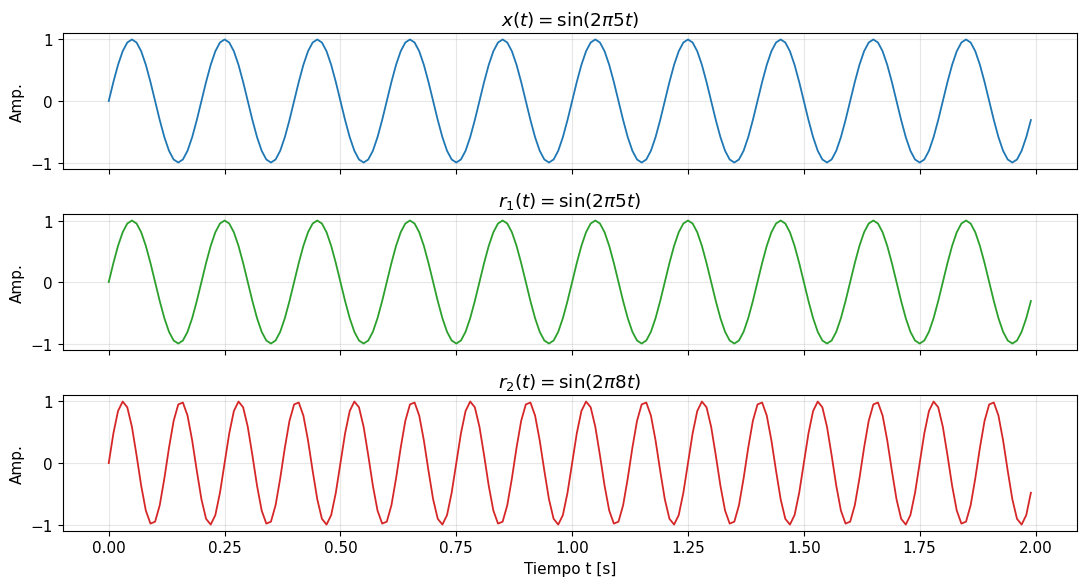

In [14]:
"""
Razonamiento:
Graficamos x(t) de 5Hz, r_1(t) de 5Hz y r_2(t) de 8Hz para poder ver las
diferencias de frecuencia.
"""
r1 = np.sin(2*np.pi*5*t)
r2 = np.sin(2*np.pi*8*t)

# (a) Graficas
fig, ax = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
for a, s, ttl, c in zip(ax, [x4, r1, r2],
                        ["$x(t)=\\sin(2\\pi 5t)$",
                         "$r_1(t)=\\sin(2\\pi 5t)$",
                         "$r_2(t)=\\sin(2\\pi 8t)$"],
                        ["C0", "C2", "C3"]):
    a.plot(t, s, lw=1.3, color=c); a.set_title(ttl); a.set_ylabel("Amp.")
ax[-1].set_xlabel("Tiempo t [s]")
plt.tight_layout(); plt.show()

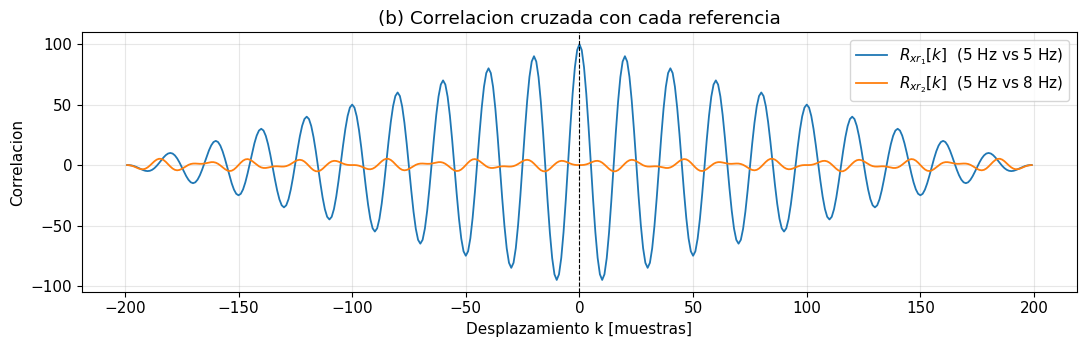

In [15]:
# (b) Las dos correlaciones cruzadas
"""
Razonamiento:
La correlación con r_1 (5Hz vs 5Hz) produce una oscilación de amplitud grande
con un pico centrado en k = 0, mientras que con r_2 (5Hz vs 8Hz) la respuesta
se mantiene con amplitudes muy bajas en todos los desplazamientos.
"""
Refs = np.vstack([r1, r2])                 # matriz (2, N)
lags_r, R_r = correlaciones_multiples(x4, Refs)
R_r1, R_r2 = R_r[0], R_r[1]
lags_r1 = lags_r2 = lags_r

plt.figure()
plt.plot(lags_r1, R_r1, lw=1.3, label="$R_{x r_1}[k]$  (5 Hz vs 5 Hz)")
plt.plot(lags_r2, R_r2, lw=1.3, label="$R_{x r_2}[k]$  (5 Hz vs 8 Hz)")
plt.axvline(0, color="k", lw=0.8, ls="--")
plt.title("(b) Correlacion cruzada con cada referencia")
plt.xlabel("Desplazamiento k [muestras]"); plt.ylabel("Correlacion")
plt.legend(); plt.tight_layout(); plt.show()

In [16]:
# (c) Comparacion de maximos absolutos
"""
Razonamiento:
Al correlacionar con r_2(t) de 8Hz, las oscilaciones se desfasaron a lo largo
del tiempo y las áreas positivas y negativas se cancelaron, dando  valores
cercanos a cero.
"""
m1, m2 = np.abs(R_r1).max(), np.abs(R_r2).max()
print(f"max |R_x,r1| = {m1:8.3f}   (referencia de 5 Hz)")
print(f"max |R_x,r2| = {m2:8.3f}   (referencia de 8 Hz)")
print(f"\nRazon r1/r2 = {m1/m2:.1f}x")
print(f"Correlacion en lag 0 con r1: {np.dot(x4, r1):.3f}   (teorico N/2 = {N/2:.0f})")
print(f"Correlacion en lag 0 con r2: {np.dot(x4, r2):.3e} (teorico 0)")

max |R_x,r1| =  100.000   (referencia de 5 Hz)
max |R_x,r2| =    5.188   (referencia de 8 Hz)

Razon r1/r2 = 19.3x
Correlacion en lag 0 con r1: 100.000   (teorico N/2 = 100)
Correlacion en lag 0 con r2: 1.277e-15 (teorico 0)


---
# Ejercicio 6 — Finding a hidden frequency

The observed signal is

x(t) = 2 sin(2π·7t)

Assume its frequency is one of {3, 5, 7, 9, 11} Hz. For every candidate frequency f, generate

r_f(t) = sin(2πft)

a) Compute the correlation of x(t) with each reference signal.

b) Store the maximum absolute correlation obtained for each frequency.

c) Plot correlation magnitude versus candidate frequency.

d) Determine the frequency present in x(t).

In [17]:
'''
Razonamiento:
En este caso la frecuencia de la señal no se le da al detector,
por lo que se prueban varias frecuencias candidatas. Por lo que
para cada una se construye una referencia sinusoidal y asi se mide
que tan fuerte es su correlacion con la señal observada. Por lo que
la frecuencia que produzca la mayor respuesta sera la que presente mayor
coincidencia con la señal
'''

def banco_referencias(frecuencias, fs, Nm):
    n = np.arange(Nm)
    fase = 2*np.pi*np.outer(np.asarray(frecuencias, float), n)/fs
    return np.sin(fase), np.cos(fase)

x6 = 2*np.sin(2*np.pi*7*t)
candidatas = np.array([3, 5, 7, 9, 11])

S6, _ = banco_referencias(candidatas, fs, N)
_, R6 = correlaciones_multiples(x6, S6)
respuestas = np.abs(R6).max(axis=1)

for f, v in zip(candidatas, respuestas):
    print(f"  f = {f:2d} Hz  ->  max|R| = {v:8.2f}")

  f =  3 Hz  ->  max|R| =     7.53
  f =  5 Hz  ->  max|R| =    15.89
  f =  7 Hz  ->  max|R| =   200.00
  f =  9 Hz  ->  max|R| =    15.89
  f = 11 Hz  ->  max|R| =     7.78


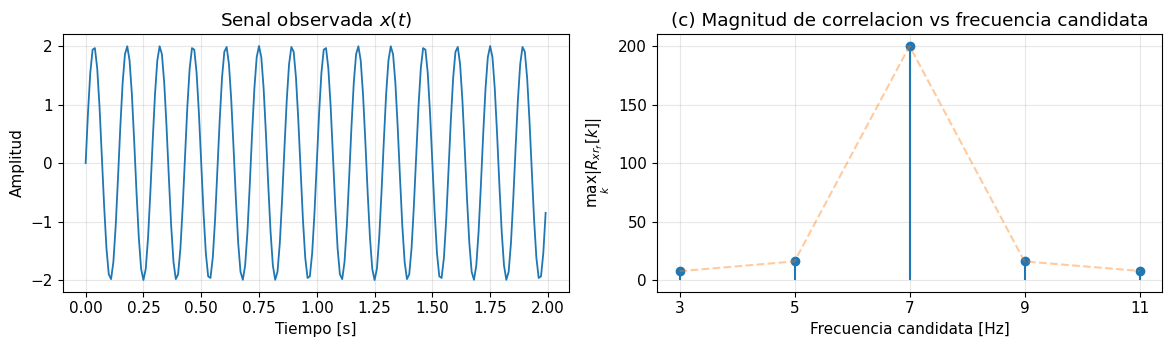

(d) Frecuencia detectada: 7 Hz
    Contraste respecto a la segunda mas alta: 12.6x


In [18]:
'''
Razonamiento:
Se realizo un barrido de diferentes frecuencias candidatas y para
cada una se calcula la magnitud de su correlacion con la señal.
Por lo que si una frecuencia candidata coincide con la frecuencia real
de la señal, la respuesta debe ser significativamente mayor que para las
demas. Por lo tanto, la frecuencia correspondiente al maximo de la
respuesta se toma como la frecuencia detectada '''

f_det = candidatas[np.argmax(respuestas)]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].plot(t, x6, lw=1.3)
ax[0].set_title("Senal observada $x(t)$"); ax[0].set_xlabel("Tiempo [s]"); ax[0].set_ylabel("Amplitud")

ax[1].stem(candidatas, respuestas, basefmt=" ")
ax[1].plot(candidatas, respuestas, "--", alpha=0.4)
ax[1].set_title("(c) Magnitud de correlacion vs frecuencia candidata")
ax[1].set_xlabel("Frecuencia candidata [Hz]"); ax[1].set_ylabel(r"$\max_k |R_{x r_f}[k]|$")
ax[1].set_xticks(candidatas)
plt.tight_layout(); plt.show()

print(f"(d) Frecuencia detectada: {f_det} Hz")
print(f"    Contraste respecto a la segunda mas alta: "
      f"{respuestas.max()/np.sort(respuestas)[-2]:.1f}x")

---
# Ejercicio 7 — Detecting two frequencies
Consider

x(t) = 2 sin(2π·5t) + 0.8 sin(2π·12t)

Sample the signal at fₛ = 100 Hz for 2 seconds. Test candidate frequencies f = {2, 3, 4, …, 20} Hz using

r_f(t) = sin(2πft)

a) Plot x(t).

b) Compute its correlation with every reference sinusoid.

c) For each frequency, obtain a single measure representing the strength of the correlation.

d) Plot correlation magnitude versus frequency.

e) Identify the two dominant frequencies.

f) Can the relative amplitudes of the two components be inferred from the correlation results? Explain.

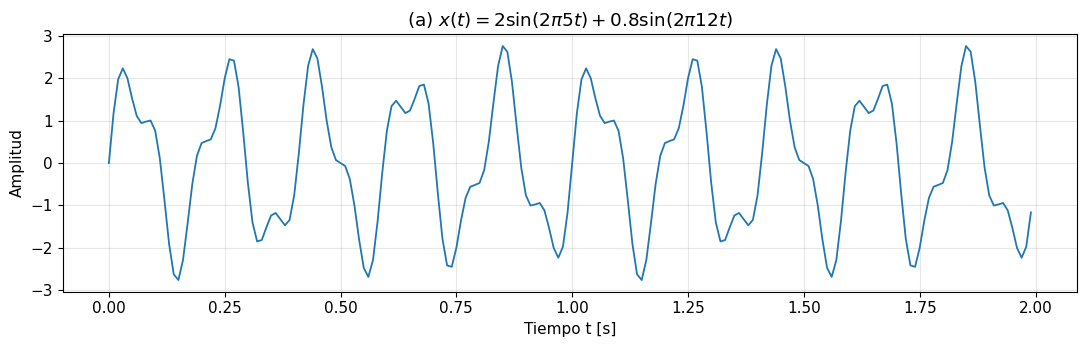

In [19]:
'''
Razonamiento:
Para esto se construye una señal compuesta por la suma de dos
sinusoides de diferentes frecuencias y amplitudes. Para esto tenemos
que comprobar si es posible identificar individualmente las dos
componentes aunque ambas esten mezcladas dentro de una misma señal. '''

x7 = 2*np.sin(2*np.pi*5*t) + 0.8*np.sin(2*np.pi*12*t)

# (a) Grafica de la senal
plt.figure()
plt.plot(t, x7, lw=1.3)
plt.title("(a) $x(t) = 2\\sin(2\\pi 5t) + 0.8\\sin(2\\pi 12t)$")
plt.xlabel("Tiempo t [s]"); plt.ylabel("Amplitud")
plt.tight_layout(); plt.show()

In [20]:
'''
Razonamiento:
Para poder detectar un componente sinusiodal no solo basta con
utilizar una unica referencia, ya que la respuesta puede depender de la
fase de la señal. Por lo que se utilizan dos referencias ortogonales
que son seno y coseno.'''

def medida_cuadratura(x, fs, frecuencias):
    x = np.asarray(x, dtype=float)
    S, C = banco_referencias(frecuencias, fs, len(x))
    Cs, Cc = S @ x, C @ x
    return (2/len(x))*np.hypot(Cs, Cc)

freqs7 = np.arange(2, 21)
S7, C7 = banco_referencias(freqs7, fs, N)


_, R7     = correlaciones_multiples(x7, S7)
resp_max  = np.abs(R7).max(axis=1)
resp_cuad = medida_cuadratura(x7, fs, freqs7)

print(" f[Hz]   max|R|      A(f) (cuadratura)")
for f, a, b in zip(freqs7, resp_max, resp_cuad):
    print(f"  {f:3d}   {a:8.2f}      {b:6.3f}")

 f[Hz]   max|R|      A(f) (cuadratura)
    2      11.49       0.000
    3      16.98       0.000
    4      32.64       0.000
    5     200.00       2.000
    6      29.68       0.000
    7      14.34       0.000
    8       8.49       0.000
    9       7.21       0.000
   10       7.46       0.000
   11      13.31       0.000
   12      80.00       0.800
   13      16.24       0.000
   14       9.25       0.000
   15       7.20       0.000
   16       5.67       0.000
   17       4.27       0.000
   18       3.89       0.000
   19       2.93       0.000
   20       3.38       0.000


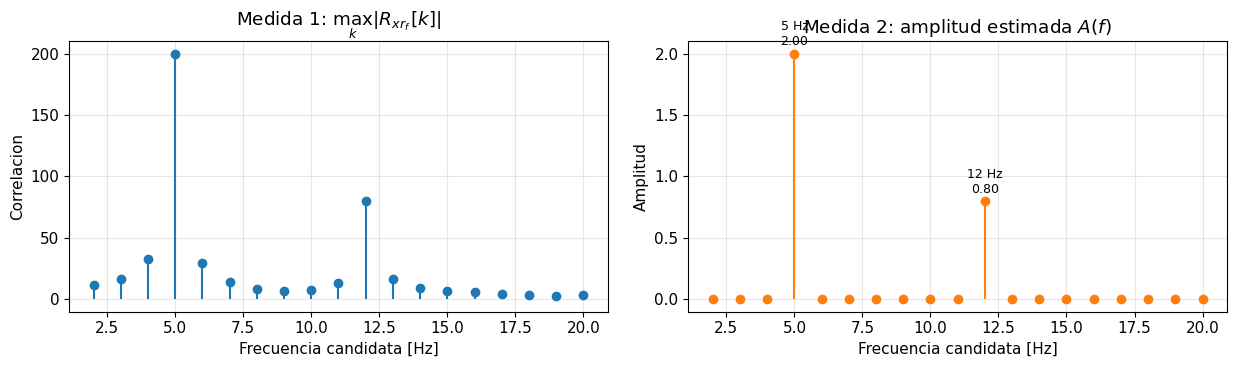

(e) Frecuencias dominantes detectadas: [np.int64(5), np.int64(12)] Hz
    Amplitudes estimadas: [2.  0.8]


In [21]:
'''
Razonamiento:
Se grafica la magnitud obtenida para cada frecuencia candidata
y se buscan los picos principales, por lo que cada pico representa
una frecuencia que tiene una coincidenia significativa con la señal.'''

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))

ax[0].stem(freqs7, resp_max, basefmt=" ")
ax[0].set_title(r"Medida 1: $\max_k |R_{x r_f}[k]|$")
ax[0].set_xlabel("Frecuencia candidata [Hz]"); ax[0].set_ylabel("Correlacion")

ax[1].stem(freqs7, resp_cuad, basefmt=" ", linefmt="C1-", markerfmt="C1o")
ax[1].set_title("Medida 2: amplitud estimada $A(f)$")
ax[1].set_xlabel("Frecuencia candidata [Hz]"); ax[1].set_ylabel("Amplitud")
for f, a in zip(freqs7, resp_cuad):
    if a > 0.3:
        ax[1].annotate(f"{f} Hz\n{a:.2f}", (f, a), textcoords="offset points",
                       xytext=(0, 6), ha="center", fontsize=9)
plt.tight_layout(); plt.show()

idx = np.argsort(resp_cuad)[::-1][:2]
print("(e) Frecuencias dominantes detectadas:", sorted(freqs7[idx]), "Hz")
print("    Amplitudes estimadas:", np.round(resp_cuad[idx], 3))

---
# Ejercicio 8 — Phase and sinusoidal detection

Consider two signals with the same frequency but different phase:

x₁(t) = sin(2π·8t)

x₂(t) = sin(2π·8t + π/3)

Initially use the sine reference

rₛ(t) = sin(2π·8t)

a) Plot x₁(t), x₂(t), and rₛ(t).

b) Compute the correlation between x₁(t) and rₛ(t).

c) Compute the correlation between x₂(t) and rₛ(t).

d) Compare the two results. Both signals have the same frequency. Why are their correlation values different?

e) Now use the cosine reference r_c(t) = cos(2π·8t) and compute its correlation with x₁(t) and x₂(t).

f) Considering the responses obtained using both sine and cosine references, explain why both are useful when the signal phase is unknown.

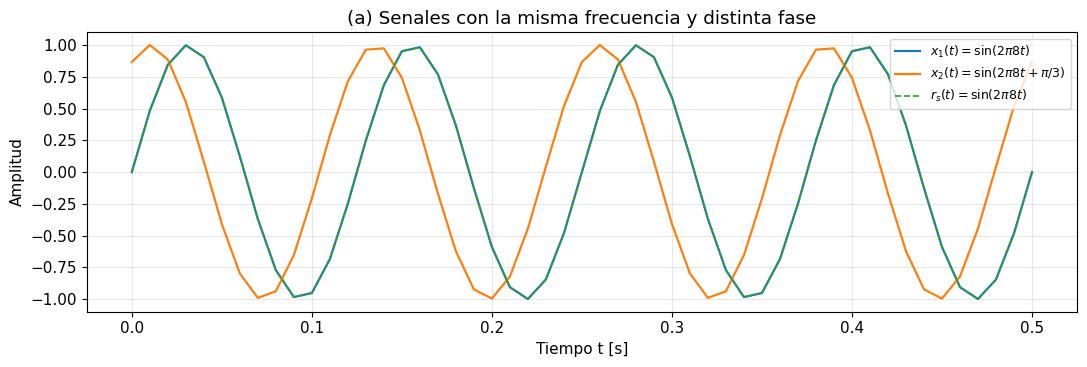

In [22]:
'''
Razonamiento:
Se generan dos señales con la misma frecuencia pero con fases
diferentes. Y esto para demostrar que la frecuencia por si sola no
determina la respuesta obtenida mediante una sola referencia. Por lo
que al cambiar la fase, cambia la relacion entre la señal y la referencia,
por lo que la correlacion puede producir valores diferentes aunque se tenga
la misma frecuencia. '''

x81 = np.sin(2*np.pi*8*t)
x82 = np.sin(2*np.pi*8*t + np.pi/3)
rs  = np.sin(2*np.pi*8*t)
rc  = np.cos(2*np.pi*8*t)

m = t <= 0.5
plt.figure(figsize=(11, 3.8))
plt.plot(t[m], x81[m], lw=1.6, label="$x_1(t)=\\sin(2\\pi 8t)$")
plt.plot(t[m], x82[m], lw=1.6, label="$x_2(t)=\\sin(2\\pi 8t+\\pi/3)$")
plt.plot(t[m], rs[m], "--", lw=1.2, label="$r_s(t)=\\sin(2\\pi 8t)$")
plt.title("(a) Senales con la misma frecuencia y distinta fase")
plt.xlabel("Tiempo t [s]"); plt.ylabel("Amplitud"); plt.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

In [23]:
'''
Razonamiento:
Se calcula la correlacion de ambas señales utilizando unicamente
una referencia seno. Y esto lo que permite es observar el efecto de la
fase sobre la respuesta. La señal que esta alineada con la referencia
produce una respuesta menor. Tambien se analiza el maximo sobre
los diferentes desplazamientos para seperar el efecto de la fase
del efecto de la alineacion temporal'''

c1s, c2s = np.dot(x81, rs), np.dot(x82, rs)
print("(b) Correlacion (lag 0) x1 . rs =", f"{c1s:8.3f}")
print("(c) Correlacion (lag 0) x2 . rs =", f"{c2s:8.3f}")
print(f"    Teorico: (N/2)cos(0) = {N/2:.1f}   y   (N/2)cos(60 deg) = {N/2*np.cos(np.pi/3):.1f}")

print("\n    max|R| sobre todos los lags:")
print("      x1 vs rs:", f"{np.abs(correlacion_cruzada(x81, rs)[1]).max():.2f}")
print("      x2 vs rs:", f"{np.abs(correlacion_cruzada(x82, rs)[1]).max():.2f}")

(b) Correlacion (lag 0) x1 . rs =  100.000
(c) Correlacion (lag 0) x2 . rs =   50.000
    Teorico: (N/2)cos(0) = 100.0   y   (N/2)cos(60 deg) = 50.0

    max|R| sobre todos los lags:
      x1 vs rs: 100.00
      x2 vs rs: 99.66


In [24]:
'''
Razonamiento:
Se utiliza el coseno para obtener la componente
que no puede observarse en el seno. Como seno y coseno estan desfasados
90° las dos dan informacion complementaria sobre la misma señal, al
combinar se puede recuperar la magnitid de la componente sin depender
de su fase '''

c1c, c2c = np.dot(x81, rc), np.dot(x82, rc)

print("           con seno r_s    con coseno r_c    sqrt(Cs^2+Cc^2)   A=2/N*|.|   fase estimada")
for nombre, cs, cc in [("x1", c1s, c1c), ("x2", c2s, c2c)]:
    mag = np.hypot(cs, cc)
    fase = np.degrees(np.arctan2(cc, cs))
    print(f"  {nombre}    {cs:10.3f}     {cc:10.3f}      {mag:10.3f}      {2/N*mag:7.3f}    {fase:7.2f} deg")

print(f"\nFase real de x1: 0 deg | Fase real de x2: {np.degrees(np.pi/3):.0f} deg")

           con seno r_s    con coseno r_c    sqrt(Cs^2+Cc^2)   A=2/N*|.|   fase estimada
  x1       100.000          0.000         100.000        1.000       0.00 deg
  x2        50.000         86.603         100.000        1.000      60.00 deg

Fase real de x1: 0 deg | Fase real de x2: 60 deg


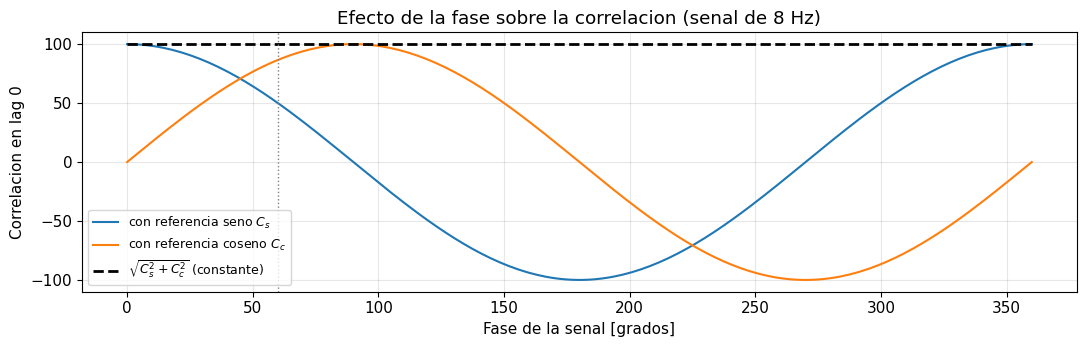

In [25]:
'''
Razonamiento:
Se analiza como cambia la respuesta de las referencias seno y
coseno al modoficar progresivamente la fase de una señal. Con esto
se comprueba graficamente que una referencia individual depende de la
fase, mientras que la combinacion de ambas componentes mantiene
constante la magnitud.'''

fases = np.linspace(0, 2*np.pi, 200)
Xfase = np.sin(2*np.pi*8*t + fases[:, None])
cs_ = Xfase @ rs
cc_ = Xfase @ rc
mag_ = np.hypot(cs_, cc_)

plt.figure()
plt.plot(np.degrees(fases), cs_, label="con referencia seno $C_s$")
plt.plot(np.degrees(fases), cc_, label="con referencia coseno $C_c$")
plt.plot(np.degrees(fases), mag_, "k--", lw=2, label=r"$\sqrt{C_s^2+C_c^2}$ (constante)")
plt.axvline(60, color="gray", ls=":", lw=1)
plt.title("Efecto de la fase sobre la correlacion (senal de 8 Hz)")
plt.xlabel("Fase de la senal [grados]"); plt.ylabel("Correlacion en lag 0")
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

---
# Ejercicio 9 — Frequency detection in white Gaussian noise

Generate the sampled signal

x[n] = sin(2π·6n/fₛ) + 0.7 sin(2π·15n/fₛ) + w[n]

using fₛ = 100 Hz. Here w[n] denotes zero-mean white Gaussian noise: independent Gaussian samples with mean 0 and a selected standard deviation σ.

a) Plot the clean signal and the noisy signal.

b) Test reference frequencies from 1 to 20 Hz.

c) Calculate the correlation response for every candidate frequency.

d) Plot correlation magnitude versus frequency.

e) Determine whether the frequencies 6 Hz and 15 Hz can still be detected.

f) Repeat for at least three different values of σ and discuss what happens as the noise level increases.

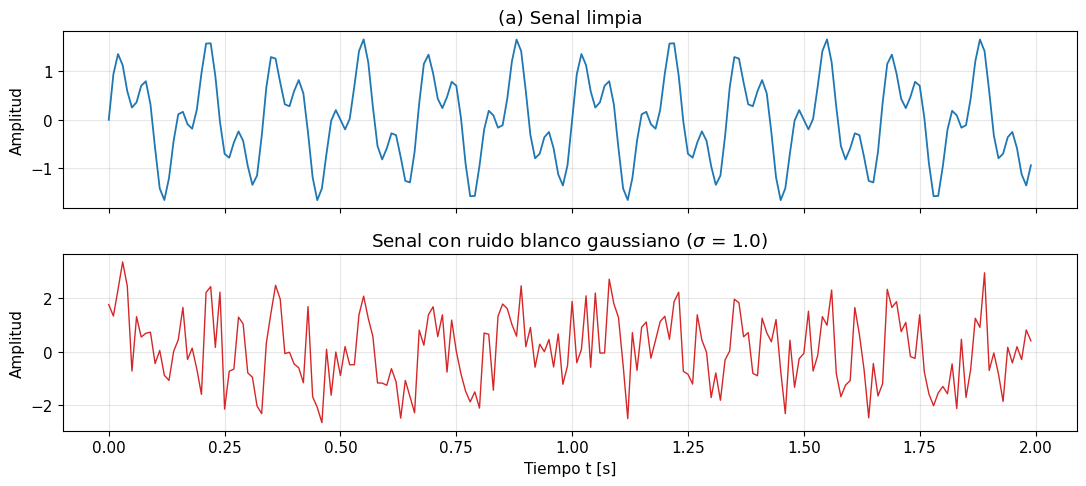

In [26]:
'''
Razonamiento:
Se genera una señal que tiene dos frecuencias y despues
se agrega ruido aleatorio. Primero se comparan ambas versiones
para observar cuanto puede afectar el ruido a la forma de onda. '''

limpia = np.sin(2*np.pi*6*t) + 0.7*np.sin(2*np.pi*15*t)
sigma_demo = 1.0
ruidosa = limpia + np.random.normal(0, sigma_demo, N)

fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax[0].plot(t, limpia, lw=1.3); ax[0].set_title("(a) Senal limpia"); ax[0].set_ylabel("Amplitud")
ax[1].plot(t, ruidosa, lw=1.0, color="C3")
ax[1].set_title(f"Senal con ruido blanco gaussiano ($\\sigma$ = {sigma_demo})")
ax[1].set_xlabel("Tiempo t [s]"); ax[1].set_ylabel("Amplitud")
plt.tight_layout(); plt.show()

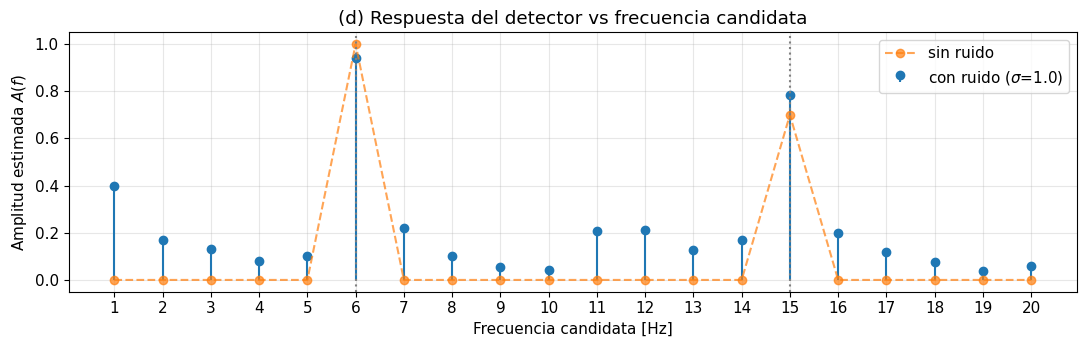

(e) Dos frecuencias con mayor respuesta: [np.int64(6), np.int64(15)] Hz
    A(6 Hz)  = 0.942  (valor real 1.0)
    A(15 Hz) = 0.783  (valor real 0.7)


In [27]:
'''
Razonamiento:
Aqui se analizo la señal ruidosa mediante un barrido de frecuencia
entre 1 y 20 Hz. Para cada frecuencia camdidata se calcula la respuesta
del detector. Las frecuencias en la señal deben generar picos, mientras
que las demas respuestas representan el efecto del ruido. '''

freqs9 = np.arange(1, 21)
resp9        = medida_cuadratura(ruidosa, fs, freqs9)
resp9_limpia = medida_cuadratura(limpia,  fs, freqs9)

plt.figure()
plt.stem(freqs9, resp9, basefmt=" ", label=f"con ruido ($\\sigma$={sigma_demo})")
plt.plot(freqs9, resp9_limpia, "o--", color="C1", alpha=0.7, label="sin ruido")
plt.axvline(6, color="gray", ls=":"); plt.axvline(15, color="gray", ls=":")
plt.title("(d) Respuesta del detector vs frecuencia candidata")
plt.xlabel("Frecuencia candidata [Hz]"); plt.ylabel("Amplitud estimada $A(f)$")
plt.xticks(freqs9); plt.legend(); plt.tight_layout(); plt.show()

top2 = freqs9[np.argsort(resp9)[::-1][:2]]
print("(e) Dos frecuencias con mayor respuesta:", sorted(top2), "Hz")
print("    A(6 Hz)  =", round(resp9[freqs9 == 6][0], 3), " (valor real 1.0)")
print("    A(15 Hz) =", round(resp9[freqs9 == 15][0], 3), " (valor real 0.7)")

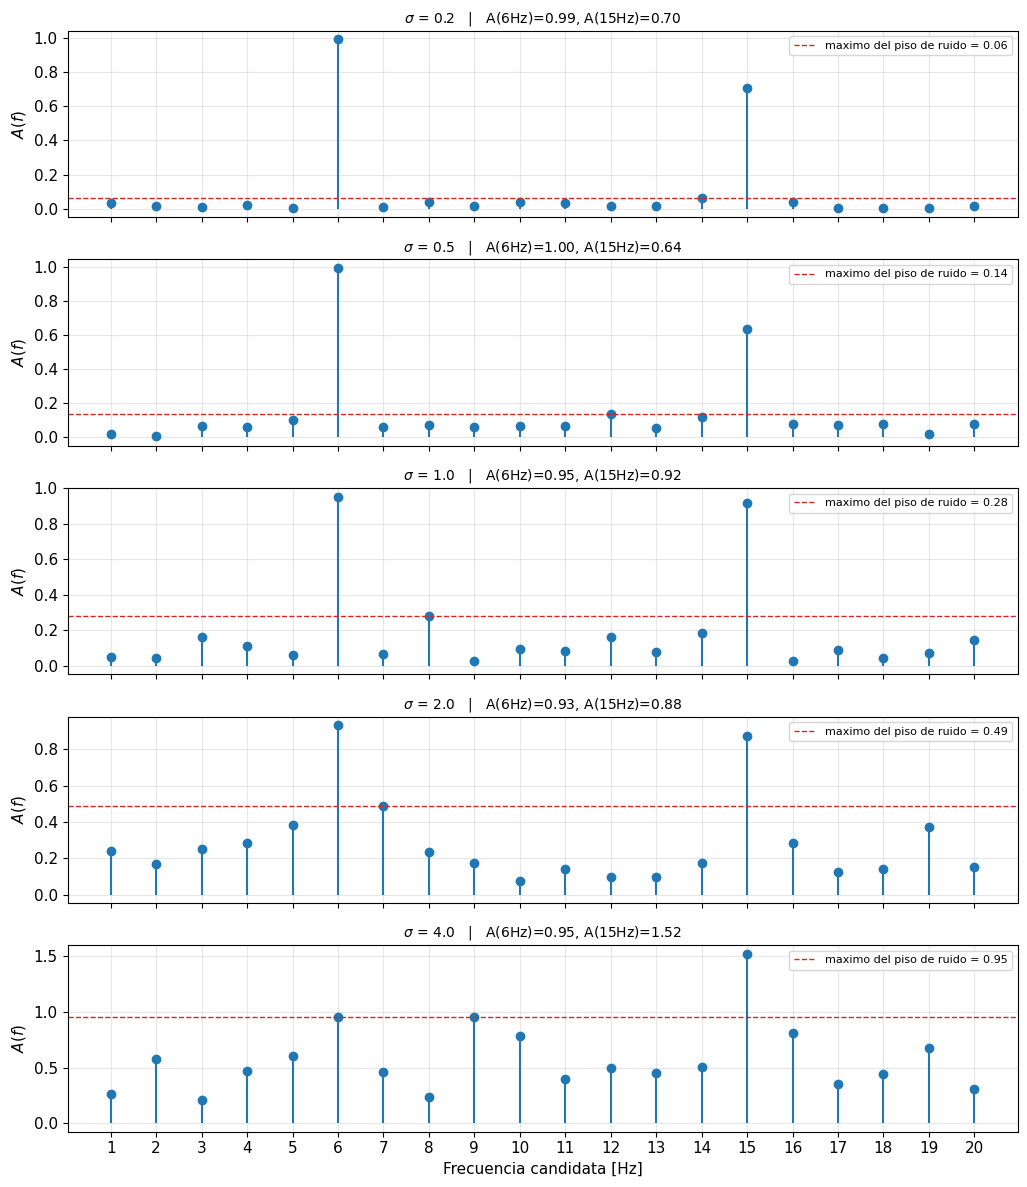

 sigma   A(6Hz)   A(15Hz)  piso medio  6Hz?   15Hz?
   0.2    0.990     0.705       0.021    SI     SI
   0.5    0.995     0.636       0.068    SI     SI
   1.0    0.953     0.918       0.100    SI     SI
   2.0    0.934     0.876       0.217    SI     SI
   4.0    0.955     1.524       0.499    SI     SI


In [28]:
'''
Razonamiento:
Se hace el mismo analisis utilzando diferentes valores
que controla la intensidad del ruido. Se quiere ver como cambia
la deteccion cuando la relacion entre señal y el ruido empeora. Para cada
nivel se observan las amplitudes detectadas en las frecuencias reales
y se comparan con las respuestas obtenidas en las frecuencias donde no
existen una componente de la señal. '''

sigmas = [0.2, 0.5, 1.0, 2.0, 4.0]

fig, axes = plt.subplots(len(sigmas), 1, figsize=(10.5, 2.4*len(sigmas)), sharex=True)
resumen = []

for ax_i, s in zip(axes, sigmas):
    xn = limpia + np.random.normal(0, s, N)
    R = medida_cuadratura(xn, fs, freqs9)

    pico6, pico15 = R[freqs9 == 6][0], R[freqs9 == 15][0]
    otras = R[(freqs9 != 6) & (freqs9 != 15)]
    piso = otras.mean()
    detect6  = pico6  > otras.max()
    detect15 = pico15 > otras.max()
    resumen.append((s, pico6, pico15, piso, detect6, detect15))

    ax_i.stem(freqs9, R, basefmt=" ")
    ax_i.axhline(otras.max(), color="C3", ls="--", lw=1,
                 label=f"maximo del piso de ruido = {otras.max():.2f}")
    ax_i.set_title(f"$\\sigma$ = {s}   |   A(6Hz)={pico6:.2f}, A(15Hz)={pico15:.2f}", fontsize=10)
    ax_i.set_ylabel("$A(f)$"); ax_i.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("Frecuencia candidata [Hz]"); axes[-1].set_xticks(freqs9)
plt.tight_layout(); plt.show()

print(f"{'sigma':>6} {'A(6Hz)':>8} {'A(15Hz)':>9} {'piso medio':>11}  6Hz?   15Hz?")
for s, p6, p15, pi, d6, d15 in resumen:
    print(f"{s:6.1f} {p6:8.3f} {p15:9.3f} {pi:11.3f}  "
          f"{'SI' if d6 else 'NO':>4}   {'SI' if d15 else 'NO':>4}")

 sigma  A(6Hz) med  A(15Hz) med  piso medio  sigma*sqrt(pi/N)   det 6Hz  det 15Hz
   0.2       1.002        0.701       0.025             0.025     100%      100%
   0.5       0.999        0.701       0.062             0.063     100%      100%
   1.0       0.992        0.709       0.124             0.125     100%      100%
   2.0       1.024        0.731       0.250             0.251      99%       82%
   4.0       1.043        0.832       0.503             0.501      49%       30%
   8.0       1.306        1.211       1.000             1.003      13%        9%


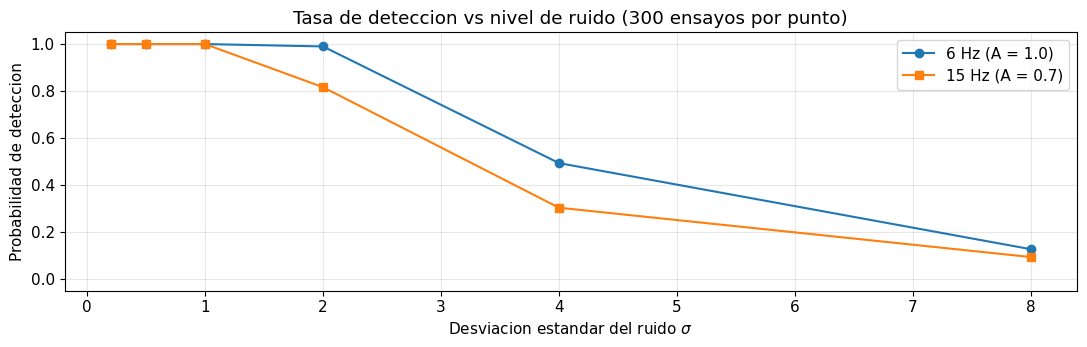

In [29]:
'''
Razonamiento:
Ya que el ruido es aleatorio, una sola realizacion no es
suficientepara determinar el comportamiento general. Se repite el
experimento muchas veces para cada nivel de ruido. Se calcula
la proporcion de ensayos en los que las frecuencias reales superan a
las demas camdidatas, y asi se obtiene una media estadistica de la
capacidad de deteccion.'''

S9, C9 = banco_referencias(freqs9, fs, N)

def tasa_deteccion(sigma, n_ensayos=300):
    """
    Fraccion de ensayos en que 6 Hz y 15 Hz superan a todas las demas candidatas.
    Los n_ensayos se procesan a la vez: X es (ensayos, N) y X @ S.T da (ensayos, F).
    """
    X = limpia + np.random.normal(0, sigma, (n_ensayos, N))
    A = (2/N)*np.hypot(X @ S9.T, X @ C9.T)

    es_senal = (freqs9 == 6) | (freqs9 == 15)
    p6, p15  = A[:, freqs9 == 6].ravel(), A[:, freqs9 == 15].ravel()
    piso     = A[:, ~es_senal]

    return ((p6  > piso.max(axis=1)).mean(),
            (p15 > piso.max(axis=1)).mean(),
            p6.mean(), p15.mean(), piso.mean())

sigmas_mc = [0.2, 0.5, 1.0, 2.0, 4.0, 8.0]
tabla = [tasa_deteccion(s) for s in sigmas_mc]

print(f"{'sigma':>6} {'A(6Hz) med':>11} {'A(15Hz) med':>12} {'piso medio':>11} "
      f"{'sigma*sqrt(pi/N)':>17} {'det 6Hz':>9} {'det 15Hz':>9}")
for s, (d6, d15, m6, m15, pi) in zip(sigmas_mc, tabla):
    print(f"{s:6.1f} {m6:11.3f} {m15:12.3f} {pi:11.3f} {s*np.sqrt(np.pi/N):17.3f} "
          f"{d6:8.0%} {d15:9.0%}")

plt.figure()
plt.plot(sigmas_mc, [x[0] for x in tabla], "o-", label="6 Hz (A = 1.0)")
plt.plot(sigmas_mc, [x[1] for x in tabla], "s-", label="15 Hz (A = 0.7)")
plt.title("Tasa de deteccion vs nivel de ruido (300 ensayos por punto)")
plt.xlabel(r"Desviacion estandar del ruido $\sigma$"); plt.ylabel("Probabilidad de deteccion")
plt.ylim(-0.05, 1.05); plt.legend(); plt.tight_layout(); plt.show()

---
# Ejercicio 10 — Build a frequency detector

Design a Python function:

detect_frequencies(x, fs, frequencies)

The function must receive a sampled signal x, sampling frequency fs, and a list of candidate frequencies, and return a measure of the presence of every candidate frequency.

Test it using

x(t) = 1.5 sin(2π·4t) + 0.7 sin(2π·9t + π/4) + 2 sin(2π·16t − π/3)

a) Search frequencies from 1 to 20 Hz.

b) Plot the original signal.

c) Plot detector response versus frequency.

d) Identify the three dominant frequencies.

e) Rank them according to their detected strength.

f) Explain why a detector using both sine and cosine references is preferable to one using only sine.

In [30]:
'''
Razonamiento:
Aqui construimos un detector general utilizando el principio
de correlacion, Para cada frecuencia se generan referencias seno
y coseno y se calculan sus correlaciones con la señal. A partir de
estas dos componentes se obtiene una magnitud asociada con la
amplitud y una fase estimada. '''

def detect_frequencies(x, fs, frequencies):
    x = np.asarray(x, dtype=float)
    Nx = len(x)
    frequencies = np.asarray(frequencies, dtype=float)


    S, C = banco_referencias(frequencies, fs, Nx)


    Cs = S @ x
    Cc = C @ x

    A  = (2/Nx)*np.hypot(Cs, Cc)
    ph = np.arctan2(Cc, Cs)

    return {"freqs": frequencies, "amplitude": A, "phase": ph, "Cs": Cs, "Cc": Cc}

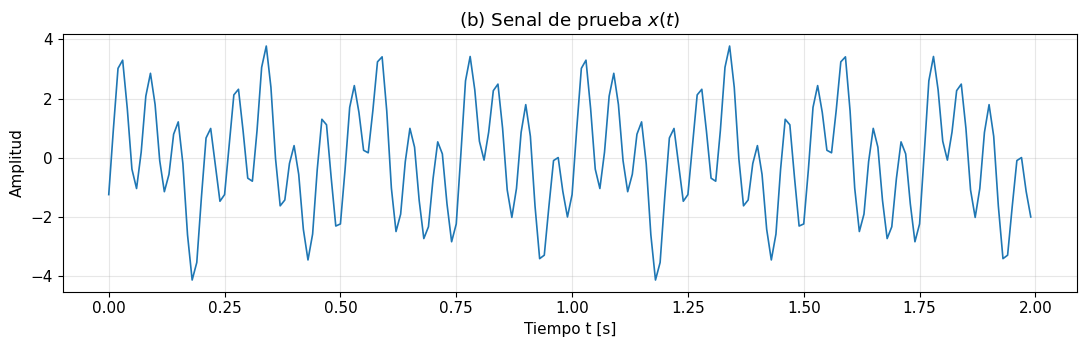

In [31]:
'''
Razonamiento:
Construimos una señal compuesta por tres componentes sinusoidales
con diferentes frecuencias, amplitudes y fases. Y estos valores
conocidos, por lo que sirven como referencia para comprobar si
funciona bien el detector. Y despues se analiza la señal utilizando
como candidatas todas las frecuencias entre 1 y 20 Hz'''

x10 = (1.5*np.sin(2*np.pi*4*t)
       + 0.7*np.sin(2*np.pi*9*t + np.pi/4)
       + 2.0*np.sin(2*np.pi*16*t - np.pi/3))

# (b) Grafica de la senal original
plt.figure()
plt.plot(t, x10, lw=1.2)
plt.title("(b) Senal de prueba $x(t)$")
plt.xlabel("Tiempo t [s]"); plt.ylabel("Amplitud")
plt.tight_layout(); plt.show()

# (a) Busqueda de 1 a 20 Hz
freqs10 = np.arange(1, 21)
res = detect_frequencies(x10, fs, freqs10)

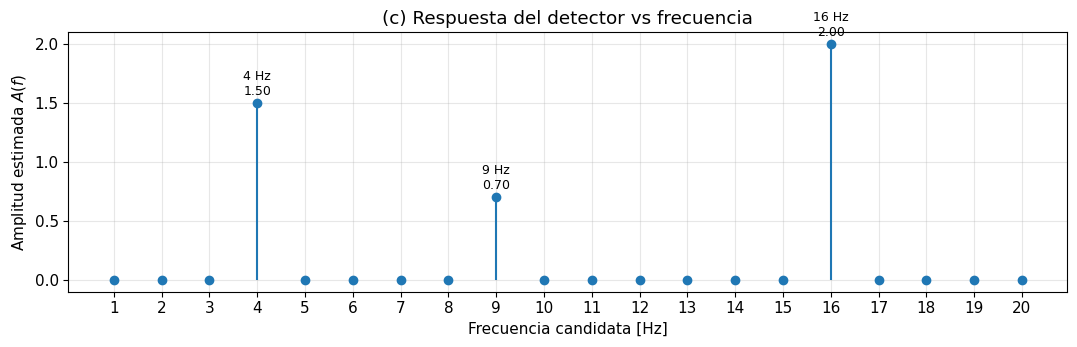

In [32]:
'''
Razonamiento:
Aqui se representa la amplitud estimada para cada funcion
candidata. Las frecuencias que forman parte de la señal deben
producir picos mayores que el resto. '''

plt.figure()
plt.stem(res["freqs"], res["amplitude"], basefmt=" ")
plt.title("(c) Respuesta del detector vs frecuencia")
plt.xlabel("Frecuencia candidata [Hz]"); plt.ylabel("Amplitud estimada $A(f)$")
plt.xticks(freqs10)
for f, a in zip(res["freqs"], res["amplitude"]):
    if a > 0.3:
        plt.annotate(f"{f:.0f} Hz\n{a:.2f}", (f, a), textcoords="offset points",
                     xytext=(0, 6), ha="center", fontsize=9)
plt.tight_layout(); plt.show()

In [33]:
'''
Razonamiento:
Aqui ordenamos la respuestas del detector para identificar
las tres componentes con mayor magnitud, y despues se comparan las
frecuencias, amplitudes y fases estimadas con los valores utilizados
orginialmente para construir la señal'''

orden = np.argsort(res["amplitude"])[::-1][:3]

print("(e) Ranking de las componentes detectadas:\n")
print(f"{'#':>2} {'f [Hz]':>7} {'A estimada':>12} {'fase [deg]':>12}   {'valores reales'}")
reales = {4: (1.5, 0.0), 9: (0.7, 45.0), 16: (2.0, -60.0)}
for i, idx in enumerate(orden, 1):
    f = int(res["freqs"][idx])
    a = res["amplitude"][idx]
    p = np.degrees(res["phase"][idx])
    ra, rp = reales[f]
    print(f"{i:>2} {f:7d} {a:12.4f} {p:12.2f}   A={ra}, fase={rp} deg")

print("\n(d) Frecuencias dominantes:", sorted(int(f) for f in res['freqs'][orden]), "Hz")
print("    Piso de ruido numerico (resto de candidatas): "
      f"{np.max([a for f, a in zip(res['freqs'], res['amplitude']) if f not in (4,9,16)]):.2e}")

(e) Ranking de las componentes detectadas:

 #  f [Hz]   A estimada   fase [deg]   valores reales
 1      16       2.0000       -60.00   A=2.0, fase=-60.0 deg
 2       4       1.5000        -0.00   A=1.5, fase=0.0 deg
 3       9       0.7000        45.00   A=0.7, fase=45.0 deg

(d) Frecuencias dominantes: [4, 9, 16] Hz
    Piso de ruido numerico (resto de candidatas): 6.17e-15


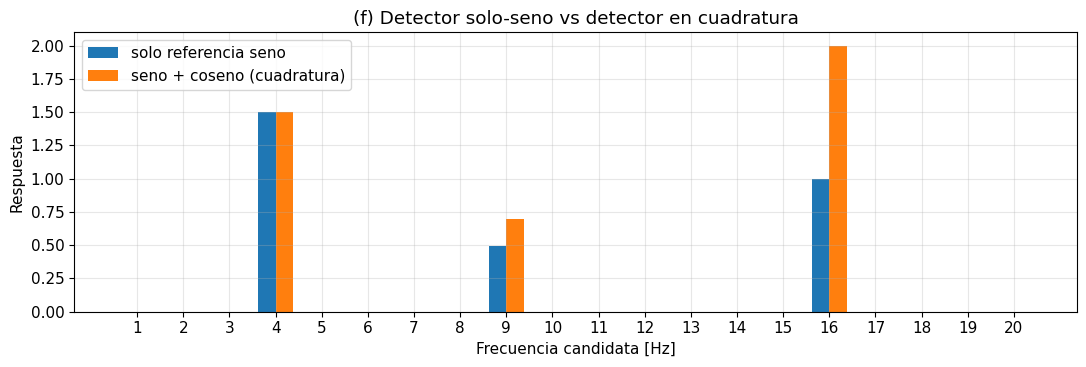

 f [Hz]   solo seno   cuadratura   A real
      4      1.5000       1.5000     1.50
      9      0.4950       0.7000     0.70
     16      1.0000       2.0000     2.00


In [34]:
'''
Razonamiento:
Y por ultimo se comparan dos metodos de deteccion, uno que
utiliza solo una referencia seno y otro que utiliza seno y coseno.
Con esta comparacion podemos comprobar el problema del ejercicio 8,
que una sola referencia puede subestimar una componente cuando
existe una diferencia de fase, y por otro lado la combinacion
en cuadratura utiliza ambas componentes para recuperar la magnitud
completa independiente de la fase '''

solo_seno = np.abs(res["Cs"])*2/N

ancho = 0.38
plt.figure(figsize=(11, 3.8))
plt.bar(freqs10 - ancho/2, solo_seno, ancho, label="solo referencia seno")
plt.bar(freqs10 + ancho/2, res["amplitude"], ancho, label="seno + coseno (cuadratura)")
plt.title("(f) Detector solo-seno vs detector en cuadratura")
plt.xlabel("Frecuencia candidata [Hz]"); plt.ylabel("Respuesta")
plt.xticks(freqs10); plt.legend(); plt.tight_layout(); plt.show()

print(f"{'f [Hz]':>7} {'solo seno':>11} {'cuadratura':>12} {'A real':>8}")
for f in (4, 9, 16):
    i = np.where(freqs10 == f)[0][0]
    print(f"{f:7d} {solo_seno[i]:11.4f} {res['amplitude'][i]:12.4f} {reales[f][0]:8.2f}")